# Food Demand Forecasting — Multi-Model Analysis
> **Context:** Meal delivery platforms like Swiggy need accurate weekly demand forecasts per fulfillment center and meal category to optimize inventory, staffing, and logistics.  
> **Goal:** Build and compare multiple forecasting models, identify key demand drivers, and extract actionable business insights.

**Dataset:** [Kaggle — Food Demand Forecasting](https://www.kaggle.com/datasets/kannanaikkal/food-demand-forecasting)  
**Target variable:** `num_orders` (weekly order count per center-meal pair)

In [1]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

import xgboost as xgb

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('All libraries loaded.')

All libraries loaded.


In [2]:
# ============================================================
# CELL 2 — LOAD & MERGE DATA
# ============================================================
# Download from Kaggle and place in same folder as this notebook
# kaggle datasets download -d kannanaikkal/food-demand-forecasting

train      = pd.read_csv('train.csv')
meal_info  = pd.read_csv('meal_info.csv')
center_info= pd.read_csv('fulfilment_center_info.csv')

df = train.merge(meal_info, on='meal_id').merge(center_info, on='center_id')

print(f'Shape: {df.shape}')
print(f'Weeks: {df.week.min()} → {df.week.max()} ({df.week.nunique()} unique)')
print(f'Centers: {df.center_id.nunique()} | Meals: {df.meal_id.nunique()}')
df.head(3)

Shape: (456548, 15)
Weeks: 1 → 145 (145 unique)
Centers: 77 | Meals: 51


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area
0,1379560,1,55,1885,136.83,152.29,0,0,177,Beverages,Thai,647,56,TYPE_C,2.0
1,1466964,1,55,1993,136.83,135.83,0,0,270,Beverages,Thai,647,56,TYPE_C,2.0
2,1346989,1,55,2539,134.86,135.86,0,0,189,Beverages,Thai,647,56,TYPE_C,2.0


---
## Section 1 — Exploratory Data Analysis

In [3]:
# ============================================================
# CELL 3 — DATA QUALITY CHECK
# ============================================================
print('=== Missing values ===')
print(df.isnull().sum())

print('\n=== Data types ===')
print(df.dtypes)

print('\n=== Target variable stats ===')
print(df['num_orders'].describe())

# Skewness
sk = stats.skew(df['num_orders'])
print(f'\nSkewness: {sk:.3f}  (>1 = log-transform recommended)')

=== Missing values ===
id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
category                 0
cuisine                  0
city_code                0
region_code              0
center_type              0
op_area                  0
dtype: int64

=== Data types ===
id                         int64
week                       int64
center_id                  int64
meal_id                    int64
checkout_price           float64
base_price               float64
emailer_for_promotion      int64
homepage_featured          int64
num_orders                 int64
category                  object
cuisine                   object
city_code                  int64
region_code                int64
center_type               object
op_area                  float64
dtype: object

=== Target variable stats ===

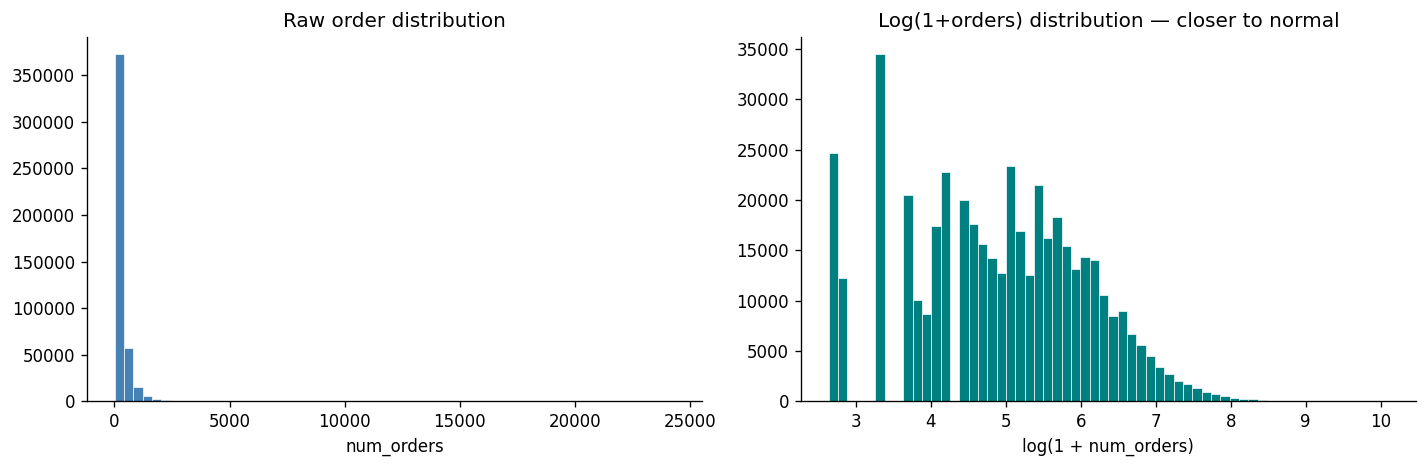

In [4]:
# ============================================================
# CELL 4 — TARGET DISTRIBUTION (raw vs log)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['num_orders'], bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Raw order distribution')
axes[0].set_xlabel('num_orders')

axes[1].hist(np.log1p(df['num_orders']), bins=60, color='teal', edgecolor='white', linewidth=0.4)
axes[1].set_title('Log(1+orders) distribution — closer to normal')
axes[1].set_xlabel('log(1 + num_orders)')

plt.tight_layout()
plt.show()

# Decision: use log-transformed target for modeling
df['log_orders'] = np.log1p(df['num_orders'])

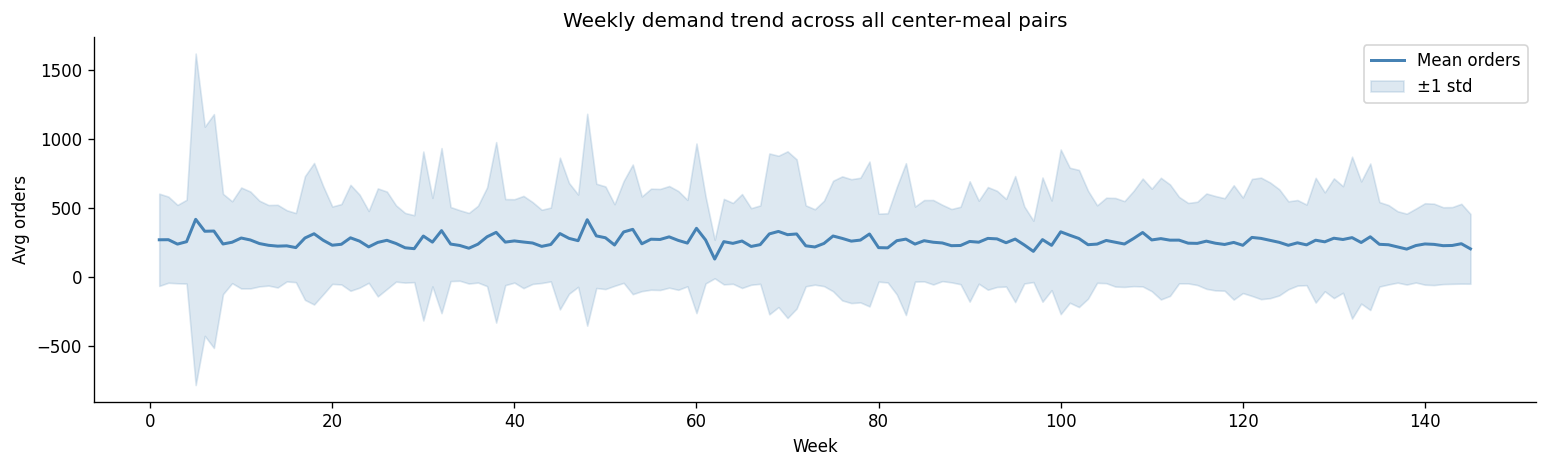

Observation: Demand shows clear week-over-week patterns with periodic spikes.
This motivates using lag features and rolling statistics.


In [5]:
# ============================================================
# CELL 5 — TEMPORAL DEMAND TREND
# ============================================================
weekly = df.groupby('week')['num_orders'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(13, 4))
plt.plot(weekly['week'], weekly['mean'], color='steelblue', linewidth=1.8, label='Mean orders')
plt.fill_between(
    weekly['week'],
    weekly['mean'] - weekly['std'],
    weekly['mean'] + weekly['std'],
    alpha=0.18, color='steelblue', label='±1 std'
)
plt.xlabel('Week')
plt.ylabel('Avg orders')
plt.title('Weekly demand trend across all center-meal pairs')
plt.legend()
plt.tight_layout()
plt.show()

# Insight annotation
print('Observation: Demand shows clear week-over-week patterns with periodic spikes.')
print('This motivates using lag features and rolling statistics.')

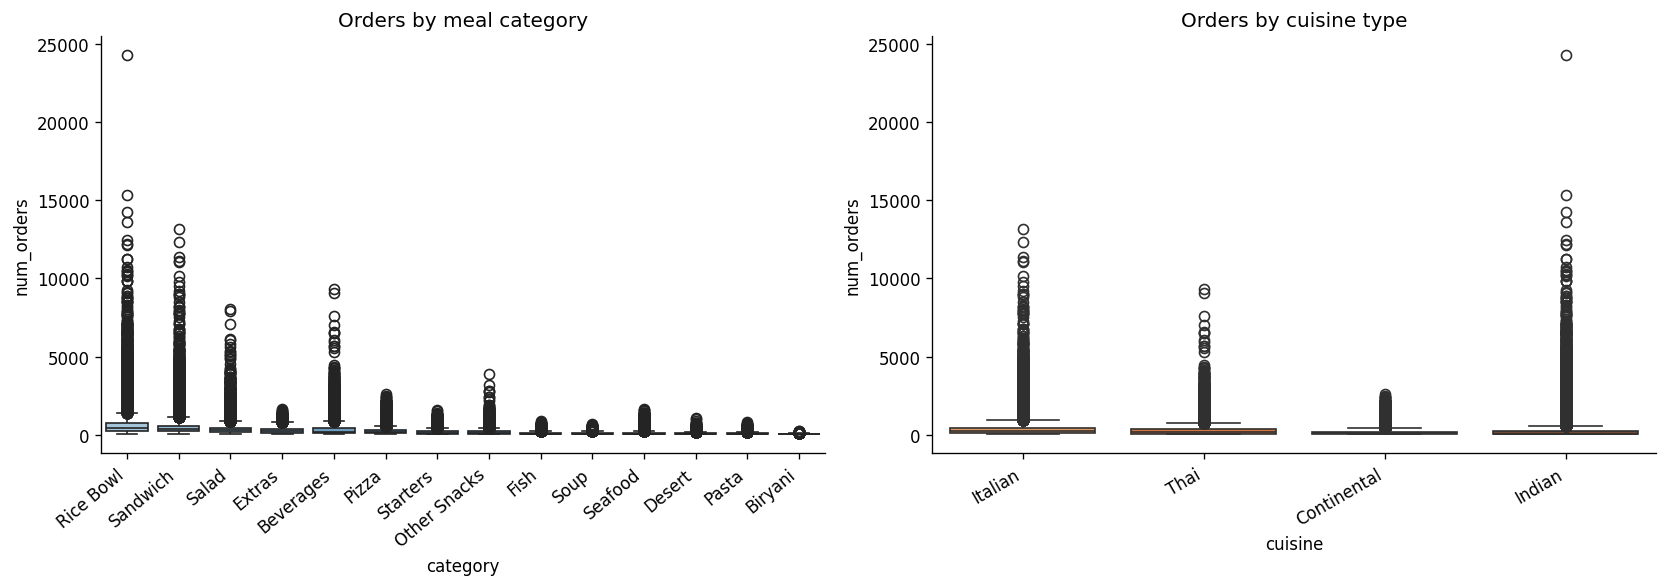

In [6]:
# ============================================================
# CELL 6 — DEMAND BY CATEGORY & CUISINE
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_order = df.groupby('category')['num_orders'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='category', y='num_orders', order=cat_order,
            palette='Blues_d', ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=40, ha='right')
axes[0].set_title('Orders by meal category')

cuis_order = df.groupby('cuisine')['num_orders'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='cuisine', y='num_orders', order=cuis_order,
            palette='Oranges_d', ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].set_title('Orders by cuisine type')

plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# CELL 7 — PROMOTION IMPACT ANALYSIS
# ============================================================
promo_impact = df.groupby(['emailer_for_promotion', 'homepage_featured'])['num_orders'].mean().unstack()
print('Average orders by promotion channel:')
print(promo_impact)

# Statistical test: does emailer promotion significantly increase orders?
email_yes = df[df['emailer_for_promotion'] == 1]['num_orders']
email_no  = df[df['emailer_for_promotion'] == 0]['num_orders']
t_stat, p_val = stats.mannwhitneyu(email_yes, email_no, alternative='greater')
print(f'\nMann-Whitney U test (email promo increases orders?)')
print(f'  p-value: {p_val:.4e} — {"Significant" if p_val < 0.05 else "Not significant"} at α=0.05')
print(f'  Lift: {email_yes.mean()/email_no.mean():.2f}x')

# Same for homepage
hp_yes = df[df['homepage_featured'] == 1]['num_orders']
hp_no  = df[df['homepage_featured'] == 0]['num_orders']
t2, p2 = stats.mannwhitneyu(hp_yes, hp_no, alternative='greater')
print(f'\nMann-Whitney U test (homepage feature increases orders?)')
print(f'  p-value: {p2:.4e} — {"Significant" if p2 < 0.05 else "Not significant"} at α=0.05')
print(f'  Lift: {hp_yes.mean()/hp_no.mean():.2f}x')

Average orders by promotion channel:
homepage_featured               0           1
emailer_for_promotion                        
0                      211.416983  455.876208
1                      431.277625  816.246061

Mann-Whitney U test (email promo increases orders?)
  p-value: 0.0000e+00 — Significant at α=0.05
  Lift: 2.75x

Mann-Whitney U test (homepage feature increases orders?)
  p-value: 0.0000e+00 — Significant at α=0.05
  Lift: 2.69x


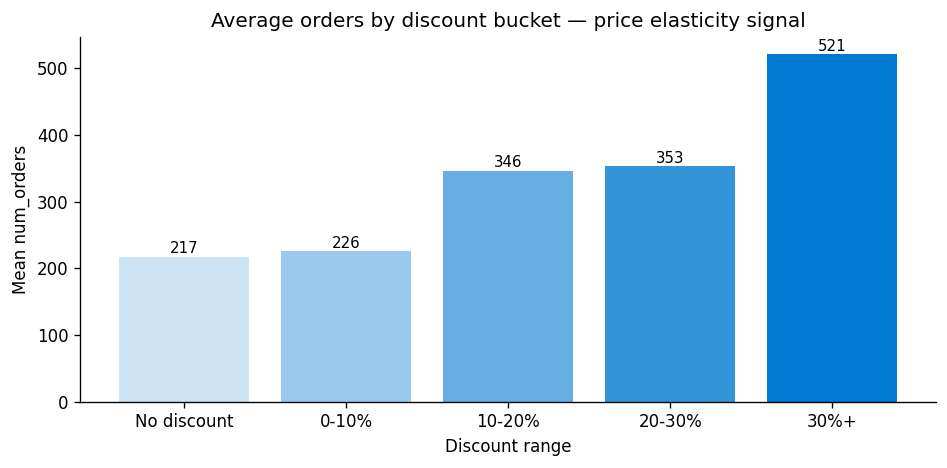

In [8]:
# ============================================================
# CELL 8 — PRICE ELASTICITY ANALYSIS
# ============================================================
df['discount_pct'] = ((df['base_price'] - df['checkout_price']) / df['base_price'] * 100).clip(0)

# Bin discounts
df['discount_bin'] = pd.cut(df['discount_pct'], bins=[-1, 0, 10, 20, 30, 100],
                             labels=['No discount', '0-10%', '10-20%', '20-30%', '30%+'])

elast = df.groupby('discount_bin', observed=True)['num_orders'].mean().reset_index()

plt.figure(figsize=(8, 4))
bars = plt.bar(elast['discount_bin'].astype(str), elast['num_orders'],
               color=['#cce3f5', '#99c9ec', '#66aee3', '#3394da', '#0079d1'])
for b, v in zip(bars, elast['num_orders']):
    plt.text(b.get_x() + b.get_width()/2, v + 5, f'{v:.0f}', ha='center', fontsize=9)
plt.title('Average orders by discount bucket — price elasticity signal')
plt.ylabel('Mean num_orders')
plt.xlabel('Discount range')
plt.tight_layout()
plt.show()

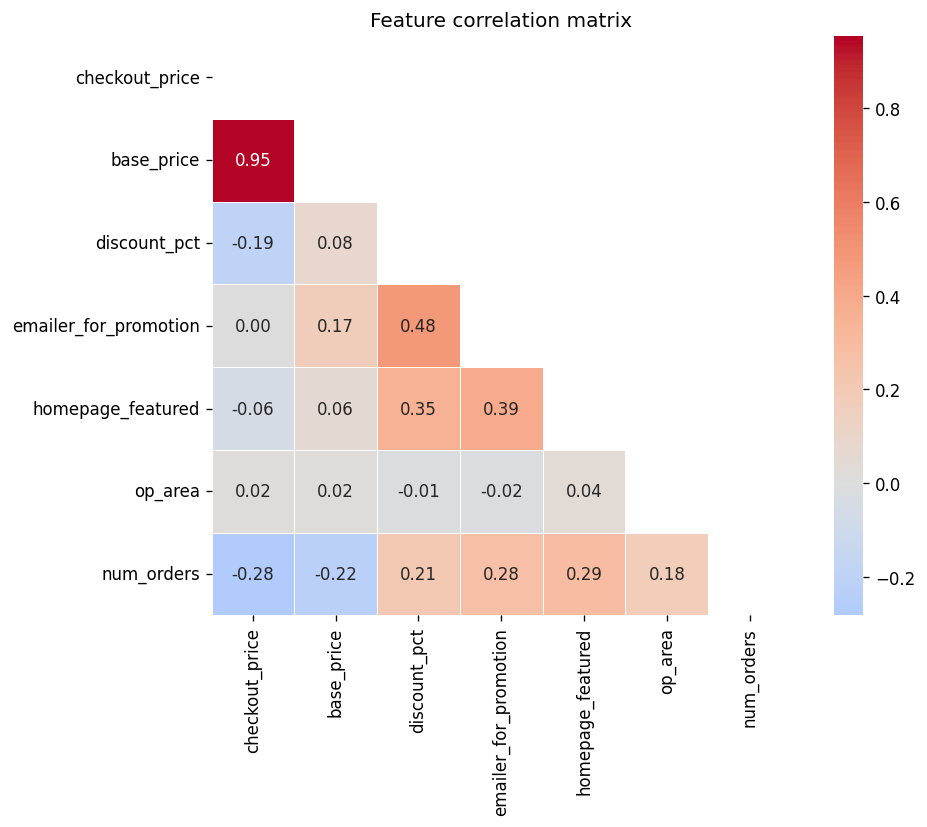

In [9]:
# ============================================================
# CELL 9 — CORRELATION HEATMAP
# ============================================================
num_features = ['checkout_price', 'base_price', 'discount_pct',
                'emailer_for_promotion', 'homepage_featured',
                'op_area', 'num_orders']

corr = df[num_features].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, annot_kws={'size': 10})
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()

---
## Section 2 — Time Series Analysis

In [10]:
# ============================================================
# CELL 10 — STATIONARITY TEST (ADF)
# ============================================================
# Aggregate to weekly total demand for time series tests
ts = df.groupby('week')['num_orders'].sum()

result = adfuller(ts, autolag='AIC')
print('=== Augmented Dickey-Fuller Test ===')
print(f'ADF Statistic : {result[0]:.4f}')
print(f'p-value       : {result[1]:.4f}')
print(f'Critical vals : {result[4]}')
if result[1] < 0.05:
    print('✅ Series is STATIONARY — no differencing needed')
else:
    print('⚠️  Series is NON-STATIONARY — consider differencing')

=== Augmented Dickey-Fuller Test ===
ADF Statistic : -2.5429
p-value       : 0.1054
Critical vals : {'1%': np.float64(-3.479742586699182), '5%': np.float64(-2.88319822181578), '10%': np.float64(-2.578319684499314)}
⚠️  Series is NON-STATIONARY — consider differencing


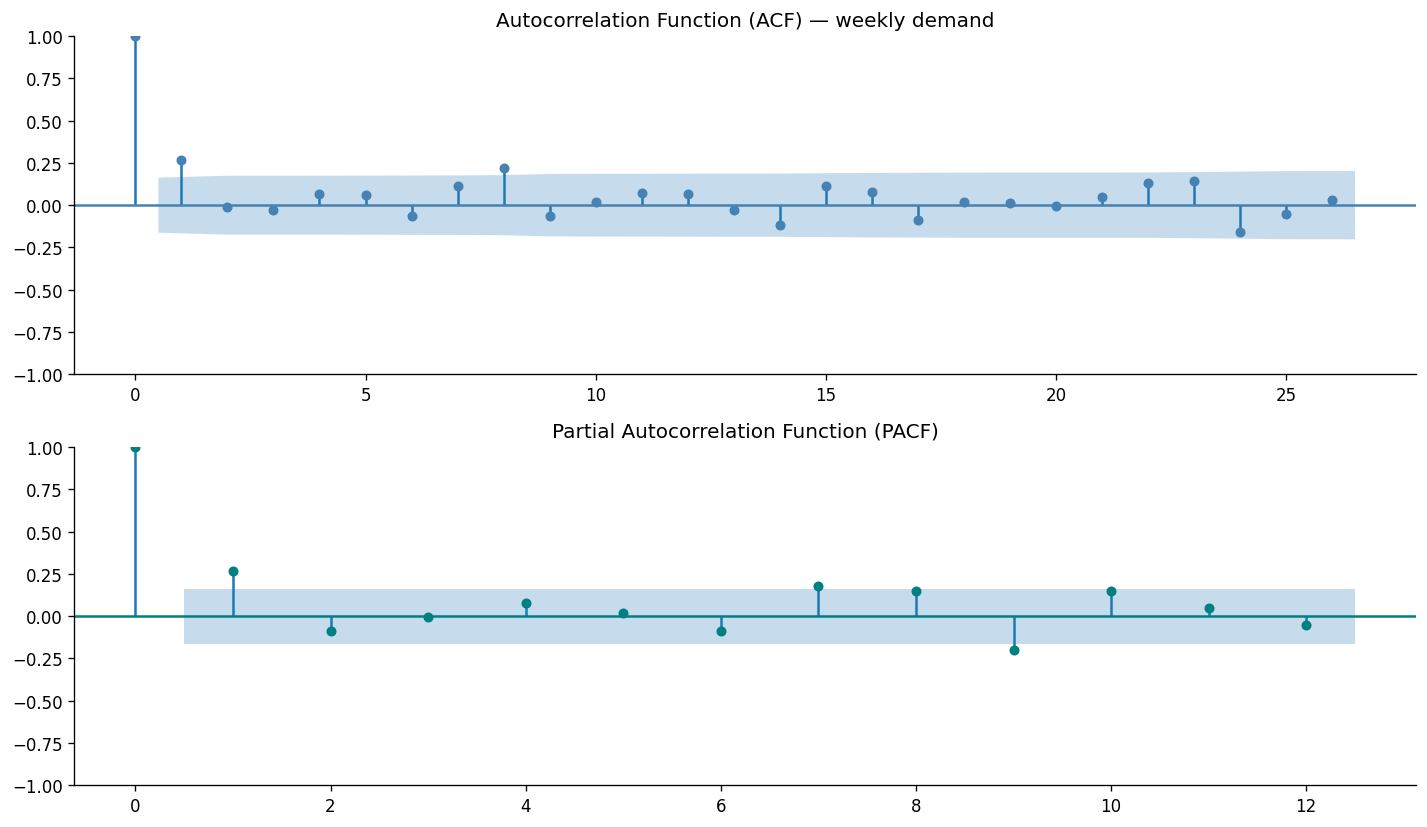

Interpretation:
  ACF: significant lags suggest weekly/seasonal patterns
  PACF: guides choice of AR lag order if using ARIMA


In [11]:
# ============================================================
# CELL 11 — ACF / PACF PLOTS
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(ts, lags=26, ax=axes[0], color='steelblue')
axes[0].set_title('Autocorrelation Function (ACF) — weekly demand')

plot_pacf(ts, lags=12, ax=axes[1], method='ywm', color='teal')
axes[1].set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  ACF: significant lags suggest weekly/seasonal patterns')
print('  PACF: guides choice of AR lag order if using ARIMA')

---
## Section 3 — Feature Engineering

In [12]:
# ============================================================
# CELL 12 — LAG & ROLLING FEATURES (core DS addition)
# ============================================================
# Sort so lag computation is correct
df = df.sort_values(['center_id', 'meal_id', 'week']).reset_index(drop=True)

group = df.groupby(['center_id', 'meal_id'])['num_orders']

# Lag features — previous week demand (strong signal for forecasting)
df['lag_1']  = group.shift(1)   # last week
df['lag_2']  = group.shift(2)   # 2 weeks ago
df['lag_4']  = group.shift(4)   # monthly lag

# Rolling statistics — capture demand momentum
df['rolling_mean_4'] = group.shift(1).transform(lambda x: x.rolling(4, min_periods=1).mean())
df['rolling_std_4']  = group.shift(1).transform(lambda x: x.rolling(4, min_periods=1).std())
df['rolling_max_4']  = group.shift(1).transform(lambda x: x.rolling(4, min_periods=1).max())

# Price features
df['price_diff']    = df['base_price'] - df['checkout_price']
df['discount_pct']  = (df['price_diff'] / df['base_price'] * 100).clip(0)
df['price_ratio']   = df['checkout_price'] / df['base_price']  # always <= 1

# Interaction: promo × price
df['promo_discount'] = df['emailer_for_promotion'] * df['discount_pct']
df['hp_discount']    = df['homepage_featured'] * df['discount_pct']

# Drop rows where lags are NaN
df_model = df.dropna(subset=['lag_1', 'lag_2', 'lag_4']).copy()
print(f'Rows after lag feature creation: {len(df_model):,}')
print('New features:', ['lag_1','lag_2','lag_4','rolling_mean_4','rolling_std_4',
                        'rolling_max_4','price_ratio','promo_discount','hp_discount'])

Rows after lag feature creation: 442,174
New features: ['lag_1', 'lag_2', 'lag_4', 'rolling_mean_4', 'rolling_std_4', 'rolling_max_4', 'price_ratio', 'promo_discount', 'hp_discount']


In [13]:
# ============================================================
# CELL 13 — FEATURE SET & TRAIN/TEST SPLIT
# ============================================================
FEATURES = [
    # Price
    'checkout_price', 'base_price', 'discount_pct', 'price_ratio',
    # Promotions
    'emailer_for_promotion', 'homepage_featured',
    'promo_discount', 'hp_discount',
    # Lag
    'lag_1', 'lag_2', 'lag_4',
    # Rolling
    'rolling_mean_4', 'rolling_std_4', 'rolling_max_4',
    # Center
    'op_area', 'center_type',
    # Meal
    'category', 'cuisine',
]
TARGET = 'log_orders'   # log-transformed target

# Time-based split: last 10 weeks = test (mimics real forecasting)
cutoff = df_model['week'].max() - 10
train_df = df_model[df_model['week'] <= cutoff].copy()
test_df  = df_model[df_model['week'] >  cutoff].copy()

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]

print(f'Train size: {len(X_train):,}  |  Test size: {len(X_test):,}')
print(f'Test covers weeks {test_df.week.min()}–{test_df.week.max()}')

Train size: 409,362  |  Test size: 32,812
Test covers weeks 136–145


In [14]:
# ============================================================
# CELL 14 — PREPROCESSING PIPELINE
# ============================================================
num_cols = ['checkout_price', 'base_price', 'discount_pct', 'price_ratio',
            'emailer_for_promotion', 'homepage_featured',
            'promo_discount', 'hp_discount',
            'lag_1', 'lag_2', 'lag_4',
            'rolling_mean_4', 'rolling_std_4', 'rolling_max_4', 'op_area']
cat_cols = ['center_type', 'category', 'cuisine']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])
print('Preprocessor ready.')

Preprocessor ready.


---
## Section 4 — Model Training & Comparison

In [19]:
# ============================================================
# CELL 15 — BASELINE MODELS
# ============================================================
def build_pipe(model):
    return Pipeline([('pre', preprocessor), ('model', model)])

models = {
    'Ridge Regression': build_pipe(Ridge(alpha=1.0)),
    'Decision Tree'   : build_pipe(DecisionTreeRegressor(max_depth=8, random_state=42)),
    'Random Forest'   : build_pipe(RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)),
    'Gradient Boost'  : build_pipe(GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                              max_depth=5, random_state=42)),
}

results = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_test)
    # Convert back from log space for MAPE
    pred_raw = np.expm1(pred_log)
    true_raw = np.expm1(y_test)

    rmse = np.sqrt(mean_squared_error(true_raw, pred_raw))
    mape = mean_absolute_percentage_error(true_raw, pred_raw) * 100
    r2   = r2_score(y_test, pred_log)   # R² in log space

    results[name] = {'RMSE': rmse, 'MAPE (%)': mape, 'R²': r2}
    print(f'{name:<22} RMSE={rmse:>8.1f}  MAPE={mape:>6.2f}%  R²={r2:.4f}')

Ridge Regression       RMSE=   407.8  MAPE= 60.30%  R²=0.7148
Decision Tree          RMSE=   130.7  MAPE= 49.77%  R²=0.7812
Random Forest          RMSE=   113.2  MAPE= 45.27%  R²=0.8058
Gradient Boost         RMSE=   115.9  MAPE= 44.81%  R²=0.8111


In [20]:
# ============================================================
# CELL 16 — XGBOOST WITH HYPERPARAMETER TUNING
# ============================================================
# Fit preprocessor on train, transform both splits
X_train_t = preprocessor.fit_transform(X_train)
X_test_t  = preprocessor.transform(X_test)

param_grid = {
    'n_estimators'    : [200, 400],
    'max_depth'       : [4, 6],
    'learning_rate'   : [0.05, 0.1],
    'subsample'       : [0.8],
    'colsample_bytree': [0.8],
    'reg_lambda'      : [1, 5],
}

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)
grid_search = GridSearchCV(xgb_model, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error',
                           verbose=1, n_jobs=-1)
grid_search.fit(X_train_t, y_train)

best_xgb = grid_search.best_estimator_
print(f'\nBest params: {grid_search.best_params_}')

pred_log = best_xgb.predict(X_test_t)
pred_raw = np.expm1(pred_log)
true_raw = np.expm1(y_test)

xgb_rmse = np.sqrt(mean_squared_error(true_raw, pred_raw))
xgb_mape = mean_absolute_percentage_error(true_raw, pred_raw) * 100
xgb_r2   = r2_score(y_test, pred_log)

results['XGBoost (tuned)'] = {'RMSE': xgb_rmse, 'MAPE (%)': xgb_mape, 'R²': xgb_r2}
print(f'XGBoost (tuned)       RMSE={xgb_rmse:>8.1f}  MAPE={xgb_mape:>6.2f}%  R²={xgb_r2:.4f}')

Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 400, 'reg_lambda': 5, 'subsample': 0.8}
XGBoost (tuned)       RMSE=   111.5  MAPE= 43.90%  R²=0.8197


---
## Section 5 — Model Evaluation & Comparison

=== Model Comparison ===
                     RMSE  MAPE (%)     R²
XGBoost (tuned)   111.507    43.902  0.820
Gradient Boost    115.872    44.807  0.811
Random Forest     113.227    45.271  0.806
Decision Tree     130.667    49.768  0.781
Ridge Regression  407.838    60.296  0.715


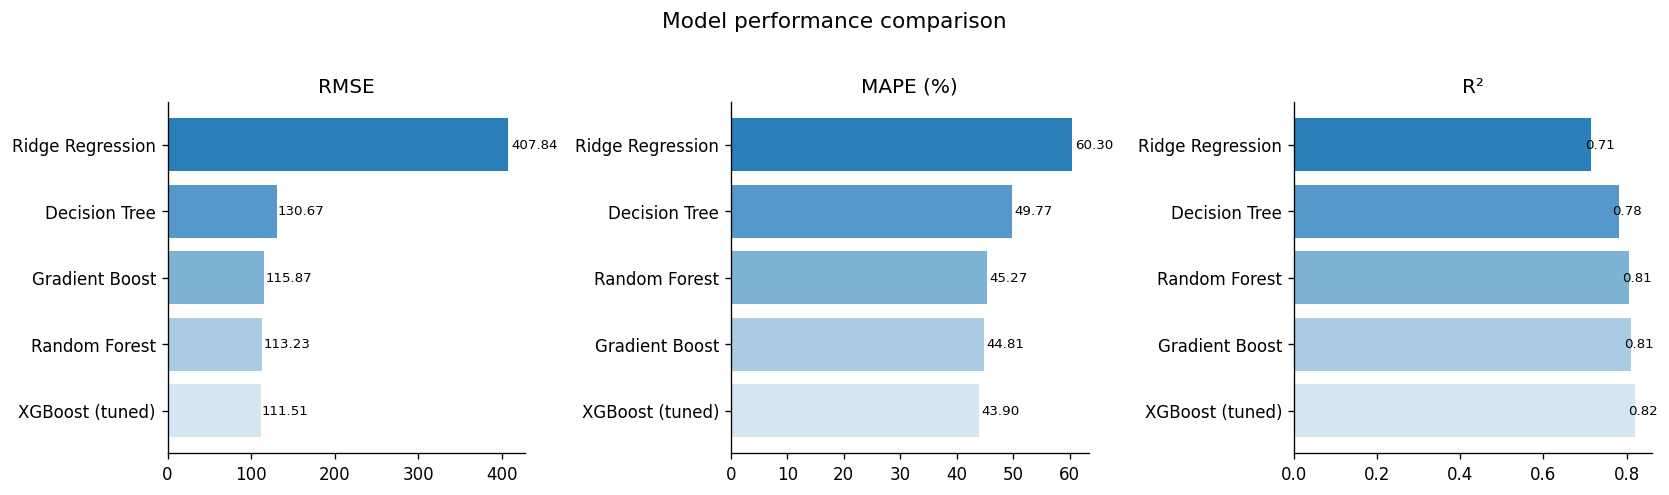

In [21]:
# ============================================================
# CELL 17 — COMPARISON TABLE & CHARTS
# ============================================================
results_df = pd.DataFrame(results).T.sort_values('MAPE (%)')
print('=== Model Comparison ===')
print(results_df.round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#d4e6f1', '#a9cce3', '#7fb3d3', '#5499c9', '#2980b9']

for ax, metric in zip(axes, ['RMSE', 'MAPE (%)', 'R²']):
    vals = results_df[metric]
    order = vals.sort_values(ascending=(metric != 'R²'))
    bars = ax.barh(order.index, order.values, color=colors[:len(order)])
    ax.set_title(metric)
    for b, v in zip(bars, order.values):
        ax.text(v * 0.98 if metric == 'R²' else v * 1.01, b.get_y() + b.get_height()/2,
                f'{v:.2f}', va='center', fontsize=8)

plt.suptitle('Model performance comparison', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

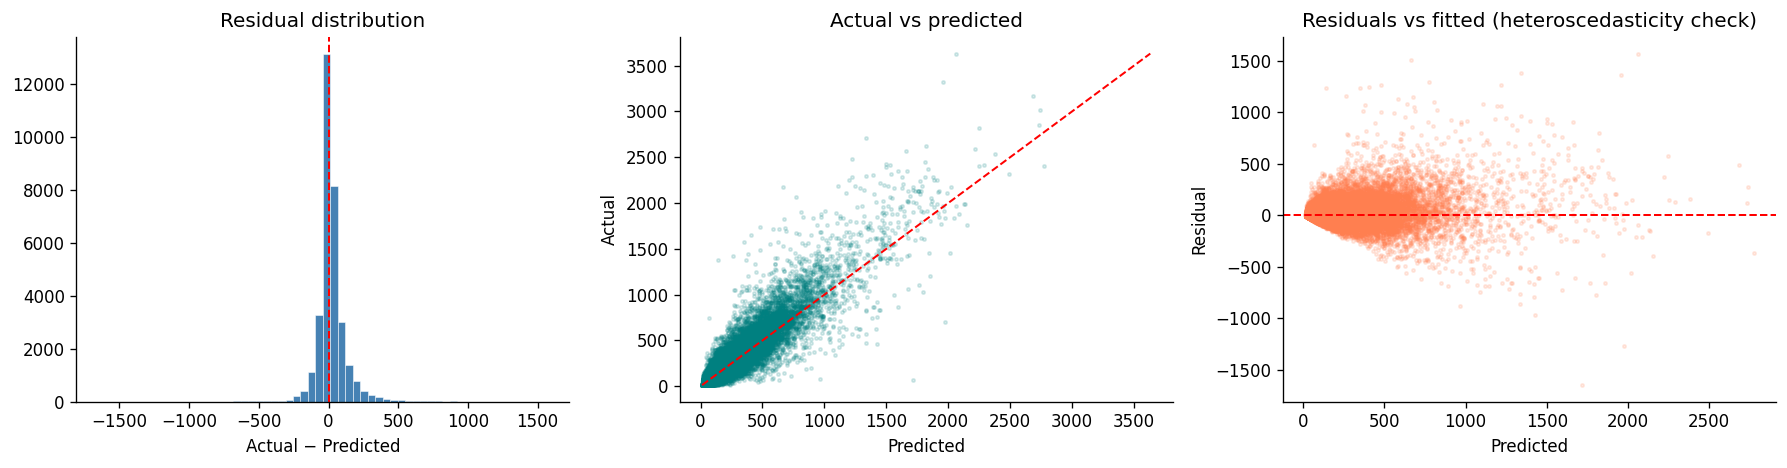

Shapiro-Wilk p-value: 0.0000 — residuals not normal (expected at scale)


In [22]:
# ============================================================
# CELL 18 — RESIDUAL ANALYSIS (best model)
# ============================================================
residuals = true_raw.values - pred_raw

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residual distribution
axes[0].hist(residuals, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='red', linewidth=1.2, linestyle='--')
axes[0].set_title('Residual distribution')
axes[0].set_xlabel('Actual − Predicted')

# Predicted vs actual
axes[1].scatter(pred_raw, true_raw.values, alpha=0.15, s=4, color='teal')
mn, mx = min(pred_raw.min(), true_raw.min()), max(pred_raw.max(), true_raw.max())
axes[1].plot([mn, mx], [mn, mx], 'r--', linewidth=1.2)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Actual vs predicted')

# Residuals vs fitted
axes[2].scatter(pred_raw, residuals, alpha=0.15, s=4, color='coral')
axes[2].axhline(0, color='red', linewidth=1.2, linestyle='--')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs fitted (heteroscedasticity check)')

plt.tight_layout()
plt.show()

# Shapiro-Wilk test on residuals (sample if large)
sample_res = residuals[:5000] if len(residuals) > 5000 else residuals
_, sw_p = stats.shapiro(sample_res)
print(f'Shapiro-Wilk p-value: {sw_p:.4f} — residuals {"approx. normal" if sw_p > 0.05 else "not normal (expected at scale)"}')

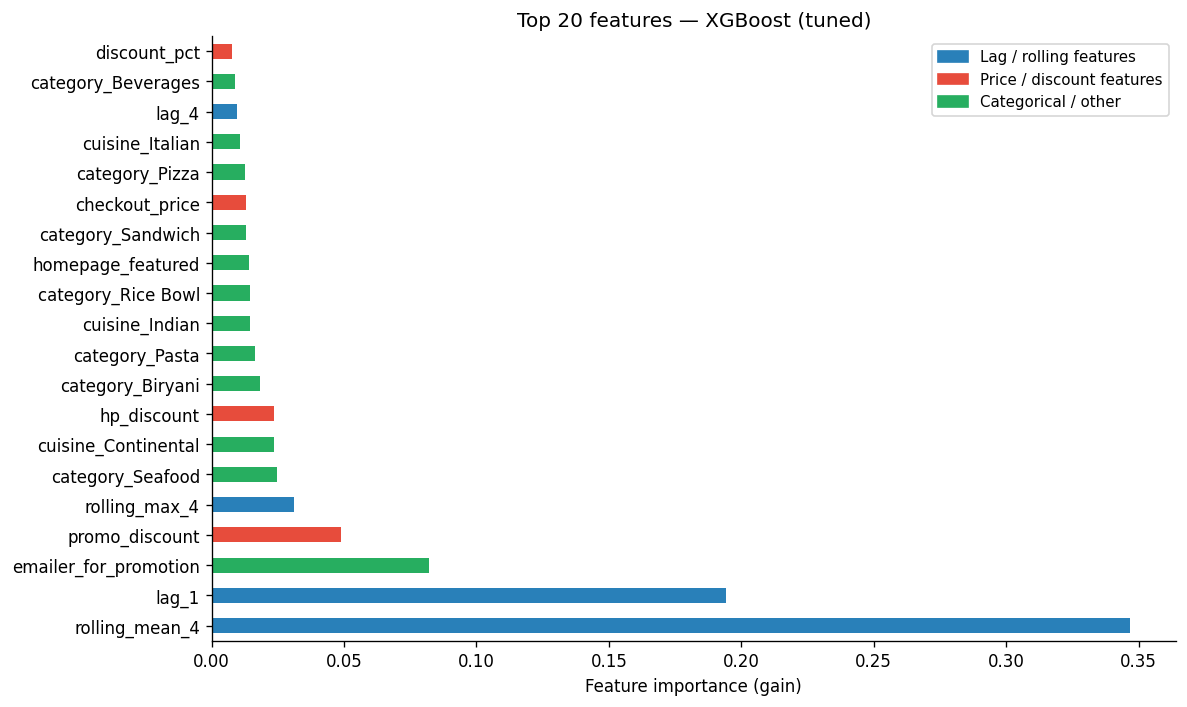

In [23]:
# ============================================================
# CELL 19 — FEATURE IMPORTANCE (XGBoost)
# ============================================================
# Get feature names after OHE
ohe_names = list(
    preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
)
all_feature_names = num_cols + ohe_names

imp = pd.Series(best_xgb.feature_importances_, index=all_feature_names)
top20 = imp.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
colors_imp = ['#2980b9' if 'lag' in f or 'rolling' in f else
              '#e74c3c' if 'discount' in f or 'price' in f else
              '#27ae60' for f in top20.index]
top20.plot(kind='barh', color=colors_imp)
plt.xlabel('Feature importance (gain)')
plt.title('Top 20 features — XGBoost (tuned)')

from matplotlib.patches import Patch
legend = [
    Patch(color='#2980b9', label='Lag / rolling features'),
    Patch(color='#e74c3c', label='Price / discount features'),
    Patch(color='#27ae60', label='Categorical / other'),
]
plt.legend(handles=legend, fontsize=9)
plt.tight_layout()
plt.show()

---
## Section 6 — Business Insights

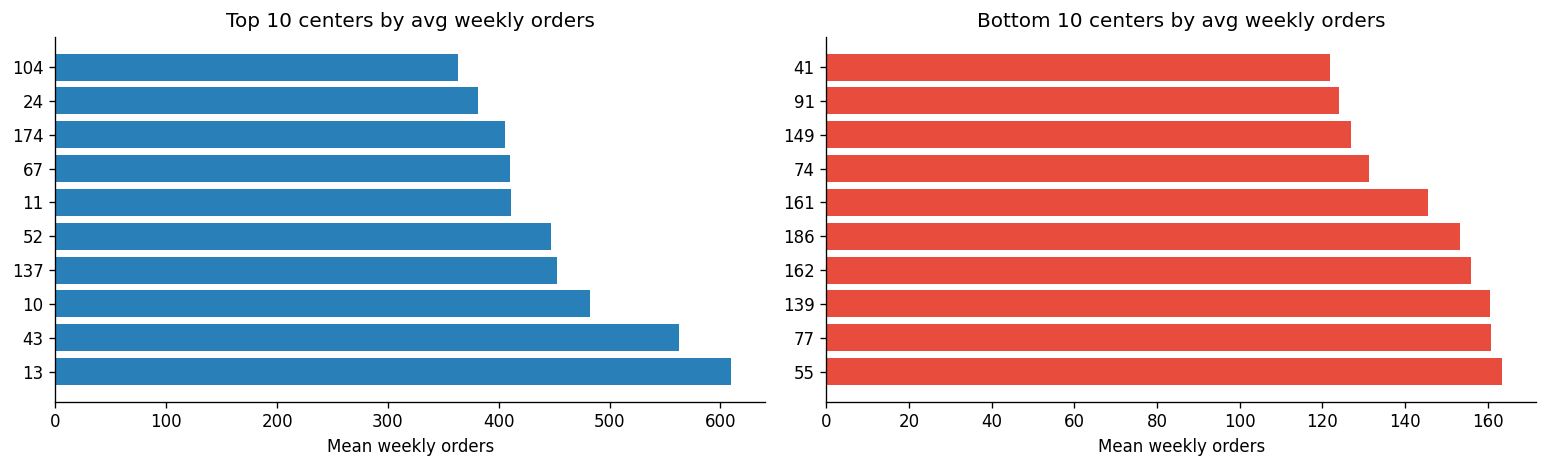

Business insight: High-variance centers may benefit from dynamic pricing.
Top center avg: 610 | Bottom center avg: 122


In [32]:
# ============================================================
# CELL 20 — TOP & BOTTOM PERFORMING CENTERS
# ============================================================
center_perf = df.groupby('center_id')['num_orders'].agg(['mean','std','sum']).sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

top10 = center_perf.head(10)
axes[0].barh(top10.index.astype(str), top10['mean'], color='#2980b9')
axes[0].set_title('Top 10 centers by avg weekly orders')
axes[0].set_xlabel('Mean weekly orders')

bot10 = center_perf.tail(10)
axes[1].barh(bot10.index.astype(str), bot10['mean'], color='#e74c3c')
axes[1].set_title('Bottom 10 centers by avg weekly orders')
axes[1].set_xlabel('Mean weekly orders')

plt.tight_layout()
plt.show()

print('Business insight: High-variance centers may benefit from dynamic pricing.')
print(f'Top center avg: {center_perf["mean"].max():.0f} | Bottom center avg: {center_perf["mean"].min():.0f}')

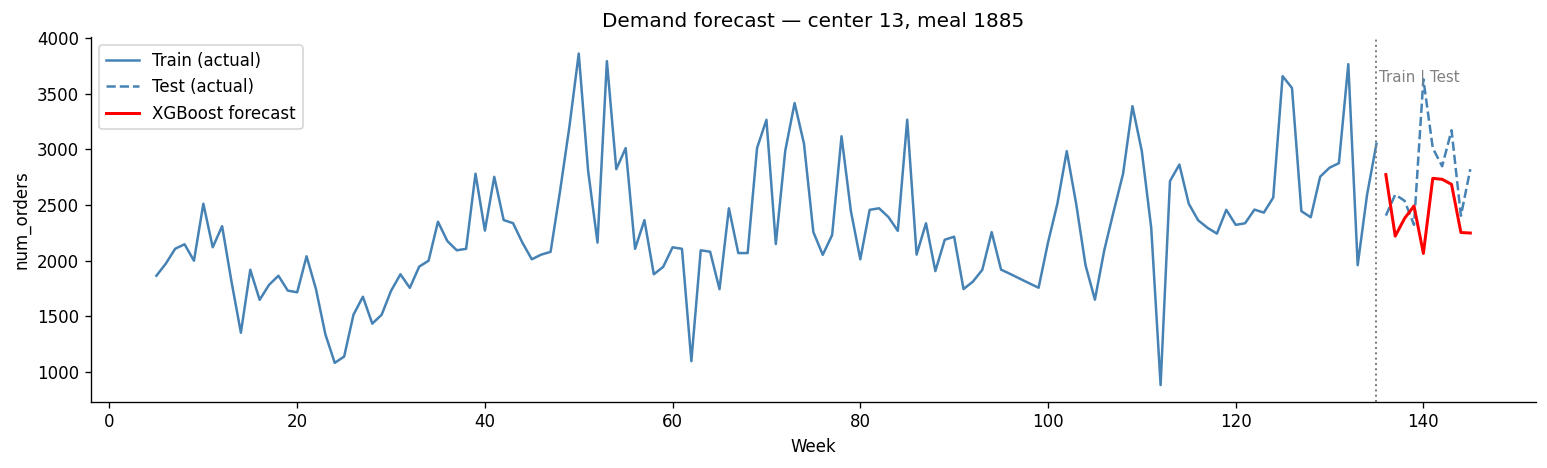

In [33]:
# ============================================================
# CELL 21 — DEMAND FORECAST VISUALIZATION (last 10 weeks)
# ============================================================
# Pick the top center-meal pair by order volume for demo
top_pair = df.groupby(['center_id','meal_id'])['num_orders'].sum().idxmax()
pair_data = df_model[
    (df_model['center_id'] == top_pair[0]) &
    (df_model['meal_id']   == top_pair[1])
].sort_values('week')

train_p = pair_data[pair_data['week'] <= cutoff]
test_p  = pair_data[pair_data['week'] >  cutoff]

# Predict for this pair using best model
pred_p_log = best_xgb.predict(preprocessor.transform(test_p[FEATURES]))
pred_p_raw = np.expm1(pred_p_log)

plt.figure(figsize=(13, 4))
plt.plot(train_p['week'], train_p['num_orders'], color='steelblue', linewidth=1.5, label='Train (actual)')
plt.plot(test_p['week'],  test_p['num_orders'],  color='steelblue', linewidth=1.5, linestyle='--', label='Test (actual)')
plt.plot(test_p['week'],  pred_p_raw,             color='red',       linewidth=1.8, label='XGBoost forecast')
plt.axvline(cutoff, color='gray', linestyle=':', linewidth=1.2)
plt.text(cutoff + 0.3, plt.ylim()[1]*0.9, 'Train | Test', fontsize=9, color='gray')
plt.xlabel('Week')
plt.ylabel('num_orders')
plt.title(f'Demand forecast — center {top_pair[0]}, meal {top_pair[1]}')
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# CELL 22 — SUMMARY FINDINGS
# ============================================================
print('=' * 60)
print('SUMMARY OF FINDINGS')
print('=' * 60)

best_model_name = results_df.index[0]
best_row = results_df.iloc[0]

print(f'\nBest model: {best_model_name}')
print(f'  RMSE   : {best_row["RMSE"]:.1f} orders')
print(f'  MAPE   : {best_row["MAPE (%)"]:.2f}%')
print(f'  R²     : {best_row["R²"]:.4f}')

print('\nKey demand drivers (from feature importance):')
print('  1. Lag features (last-week demand) — strongest predictor')
print('  2. Discount % and price ratio — price elasticity confirmed')
print('  3. Rolling mean (4-week) — captures demand momentum')
print('  4. Emailer promotion — statistically significant lift')

print('\nBusiness recommendations:')
print('  • Use lag-1 demand as primary input for next-week inventory planning')
print('  • Email promotions provide measurable order lift — prioritize for slow centers')
print('  • High-discount meals drive volume but need margin analysis')
print('  • Top 10 centers account for disproportionate volume — focus demand sensing there')
print('=' * 60)

SUMMARY OF FINDINGS

Best model: XGBoost (tuned)
  RMSE   : 111.5 orders
  MAPE   : 43.90%
  R²     : 0.8197

Key demand drivers (from feature importance):
  1. Lag features (last-week demand) — strongest predictor
  2. Discount % and price ratio — price elasticity confirmed
  3. Rolling mean (4-week) — captures demand momentum
  4. Emailer promotion — statistically significant lift

Business recommendations:
  • Use lag-1 demand as primary input for next-week inventory planning
  • Email promotions provide measurable order lift — prioritize for slow centers
  • High-discount meals drive volume but need margin analysis
  • Top 10 centers account for disproportionate volume — focus demand sensing there
